In [5]:
from langgraph.graph import StateGraph, START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm=ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.3
)

In [4]:
class jokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [7]:
def generate_joke(state:jokeState):
    prompt=f'generate a joke on the topic {state['topic']}'
    response=llm.invoke(prompt)
    return {'joke':response}

In [8]:
def joke_explanation(state:jokeState):
    prompt=f'explain the following joke {state['joke']}'
    response=llm.invoke(prompt)
    return {'explanation':response}

In [9]:
graph=StateGraph(jokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('joke_explanation',joke_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','joke_explanation')
graph.add_edge('joke_explanation',END)

checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

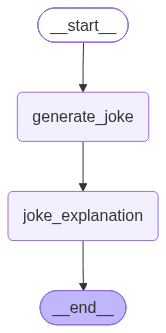

In [14]:
workflow

In [16]:
config2={'configurable':{'thread_id':'2'}}
workflow.invoke({'topic':'pasta'},config=config2)

{'topic': 'pasta',
 'joke': AIMessage(content='Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop feeling *twisted* and was always *knot* sure what to do!', additional_kwargs={'reasoning_content': "We need to generate a joke on the topic pasta. It's a simple request. We should produce a joke. Possibly a pun. Let's craft a witty one-liner. Ensure it's appropriate. Let's produce a short joke."}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 78, 'total_tokens': 163, 'completion_time': 0.089205407, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.00432716, 'prompt_tokens_details': None, 'queue_time': 0.31643731, 'total_time': 0.093532567}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a094be-8540-7543-809c-1e9f01181ccc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

In [19]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop feeling *twisted* and was always *knot* sure what to do!', additional_kwargs={'reasoning_content': "We need to generate a joke on the topic pasta. It's a simple request. We should produce a joke. Possibly a pun. Let's craft a witty one-liner. Ensure it's appropriate. Let's produce a short joke."}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 78, 'total_tokens': 163, 'completion_time': 0.089205407, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.00432716, 'prompt_tokens_details': None, 'queue_time': 0.31643731, 'total_time': 0.093532567}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a094be-8540-7543-809c-1e9f01181ccc-0', tool_calls=[], invalid_tool_calls=[], 